In [2]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geocat.viz as gv
import matplotlib.path as mpath

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

EBAF =  89.92634 439.12912
ERA5 =  97.98915 439.00095
EBAF =  67.278076 440.65448
ERA5 =  78.16436 437.85474
EBAF =  66.723656 479.9602
ERA5 =  75.77929 469.30536
EBAF =  85.14156 443.57584
ERA5 =  76.79525 439.1615


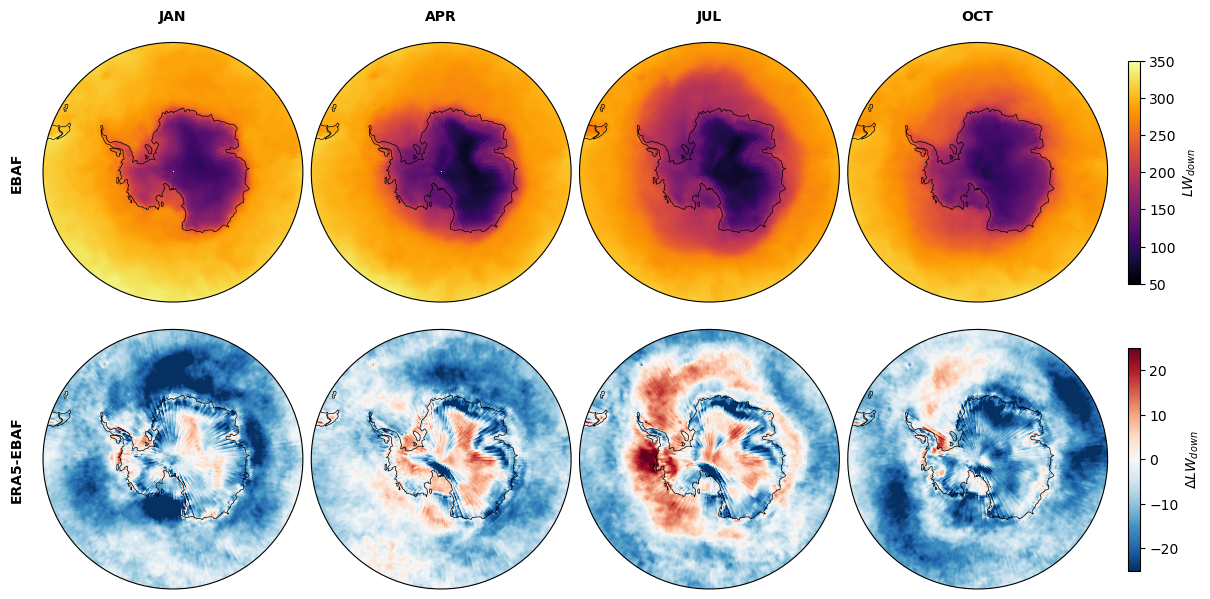

In [10]:
# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(2, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': proj})

icol = 0
for label, val in months.items():
    # Load datasets
    ds_era5 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_era5/era5_35d_monthly.nc"))
    ds_ebaf = xr.open_dataset(os.path.join(data_path, 'CERES_EBAF_Ed4.2.1_Subset_200003-202509_remap.nc'))

    # CERES EBAF
    ds_ebaf = ds_ebaf.sel(time=f'2021-{val:02d}-15T00:00:00')
    data_ebaf = ds_ebaf.sfc_lw_down_all_mon
    ax[0,icol].set_boundary(circle, transform=ax[0,icol].transAxes)
    ax[0,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    ax[0,icol].coastlines(linewidth=0.5)
    im0 = data_ebaf.plot(ax=ax[0,icol], transform=ccrs.PlateCarree(), vmin=50, vmax=350, cmap='inferno', add_colorbar=False)

    # ERA5
    data_era5 = ds_era5.strd.isel(valid_time=0)
    data_era5 = data_era5/3600.0
    data_era5_diff = data_era5-data_ebaf
    ax[1,icol].set_boundary(circle, transform=ax[1,icol].transAxes)
    ax[1,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    ax[1,icol].coastlines(linewidth=0.5)
    im1 = data_era5_diff.plot(ax=ax[1,icol], transform=ccrs.PlateCarree(), vmin=-25, vmax=25, cmap='RdBu_r', add_colorbar=False)

    # Print min and max
    print("EBAF = ", data_ebaf.min().values, data_ebaf.max().values)
    print("ERA5 = ", data_era5.min().values, data_era5.max().values)

    # Add colorbar
    if icol == 3:
        fig.colorbar(im0, ax=ax[0,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$LW_{down}$')
        fig.colorbar(im1, ax=ax[1,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta LW_{down}$')

    # Add title to the left
    if icol == 0:
        ax[0,icol].text(-0.1, 0.5, 'EBAF', transform=ax[0,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)
        ax[1,icol].text(-0.1, 0.5, 'ERA5-EBAF', transform=ax[1,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    # Add title to the top
    ax[0,icol].text(0.5, 1.1, f"{label}", transform=ax[0,icol].transAxes, ha='center', va='center', fontweight='bold', fontsize=10)

    # Remove titles
    ax[0,icol].set_title("")
    ax[1,icol].set_title("")

    icol = icol+1

EBAF =  0.0 425.1775
ERA5 =  0.0 410.59247
EBAF =  0.0 354.11456
ERA5 =  0.0 347.0095
EBAF =  0.0 357.82407
ERA5 =  0.0 366.1676
EBAF =  0.0 358.9144
ERA5 =  0.0 367.11813


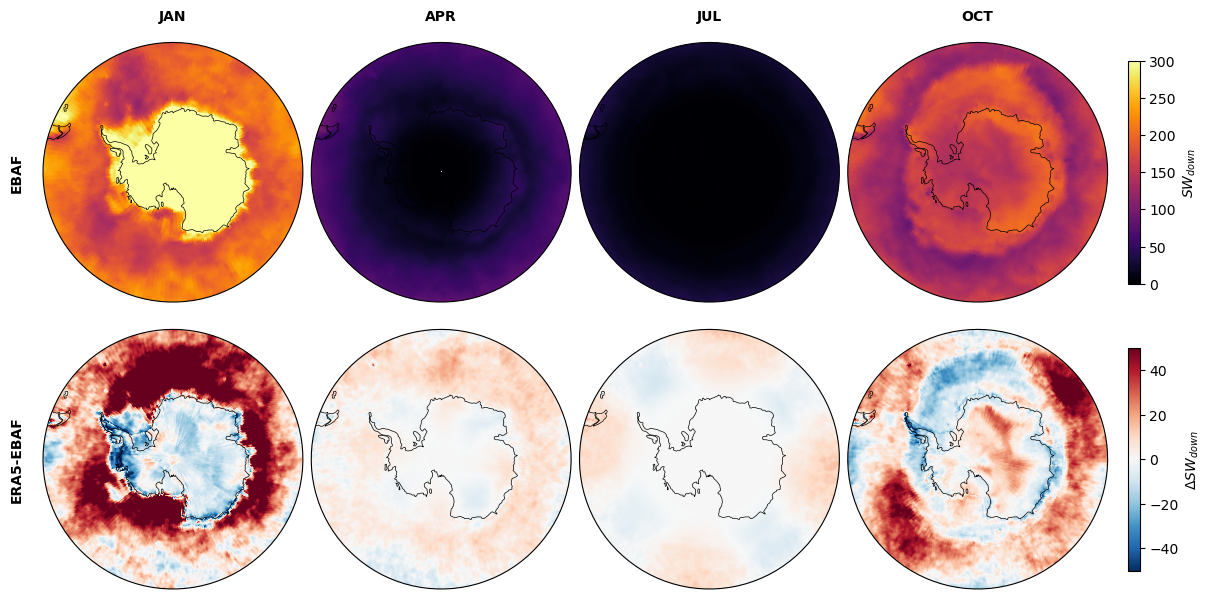

In [11]:
# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(2, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': proj})

icol = 0
for label, val in months.items():
    # Load datasets
    ds_era5 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_era5/era5_35d_monthly.nc"))
    ds_ebaf = xr.open_dataset(os.path.join(data_path, 'CERES_EBAF_Ed4.2.1_Subset_200003-202509_remap.nc'))

    # CERES EBAF
    ds_ebaf = ds_ebaf.sel(time=f'2021-{val:02d}-15T00:00:00')
    data_ebaf = ds_ebaf.sfc_sw_down_all_mon
    ax[0,icol].set_boundary(circle, transform=ax[0,icol].transAxes)
    ax[0,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    ax[0,icol].coastlines(linewidth=0.5)
    im0 = data_ebaf.plot(ax=ax[0,icol], transform=ccrs.PlateCarree(), vmin=0, vmax=300, cmap='inferno', add_colorbar=False)

    # ERA5
    data_era5 = ds_era5.ssrd.isel(valid_time=0)
    data_era5 = data_era5/3600.0
    data_era5_diff = data_era5-data_ebaf
    ax[1,icol].set_boundary(circle, transform=ax[1,icol].transAxes)
    ax[1,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    ax[1,icol].coastlines(linewidth=0.5)
    im1 = data_era5_diff.plot(ax=ax[1,icol], transform=ccrs.PlateCarree(), vmin=-50, vmax=50, cmap='RdBu_r', add_colorbar=False)

    # Print min and max
    print("EBAF = ", data_ebaf.min().values, data_ebaf.max().values)
    print("ERA5 = ", data_era5.min().values, data_era5.max().values)

    # Add colorbar
    if icol == 3:
        fig.colorbar(im0, ax=ax[0,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$SW_{down}$')
        fig.colorbar(im1, ax=ax[1,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta SW_{down}$')

    # Add title to the left
    if icol == 0:
        ax[0,icol].text(-0.1, 0.5, 'EBAF', transform=ax[0,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)
        ax[1,icol].text(-0.1, 0.5, 'ERA5-EBAF', transform=ax[1,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    # Add title to the top
    ax[0,icol].text(0.5, 1.1, f"{label}", transform=ax[0,icol].transAxes, ha='center', va='center', fontweight='bold', fontsize=10)

    # Remove titles
    ax[0,icol].set_title("")
    ax[1,icol].set_title("")

    icol = icol+1

In [ ]:
# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(2, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': proj})

# Variables
vars = {
    'sfc_sw_down_all_mon': 'ssrd',
    'sfc_net_sw_all_mon': 'ssr',
    'sfc_lw_down_all_mon': 'strd',
    'sfc_net_lw_all_mon': 'str',
}

# Month
mm = 1

icol = 0
for var1, var2 in vars.items():
    # Load datasets
    ds_era5 = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_era5/era5_35d_monthly.nc"))
    ds_ebaf = xr.open_dataset(os.path.join(data_path, 'CERES_EBAF_Ed4.2.1_Subset_200003-202509_remap.nc'))

    # CERES EBAF
    ds_ebaf = ds_ebaf.sel(time=f'2021-{mm:02d}-15T00:00:00')
    data_ebaf = ds_ebaf[var1]
    ax[0,icol].set_boundary(circle, transform=ax[0,icol].transAxes)
    ax[0,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    ax[0,icol].coastlines(linewidth=0.5)
    im0 = data_ebaf.plot(ax=ax[0,icol], transform=ccrs.PlateCarree(), vmin=0, vmax=300, cmap='inferno', add_colorbar=False)

    # ERA5
    data_era5 = ds_era5[var2].isel(valid_time=0)
    data_era5 = data_era5/3600.0
    data_era5_diff = data_era5-data_ebaf
    ax[1,icol].set_boundary(circle, transform=ax[1,icol].transAxes)
    ax[1,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    ax[1,icol].coastlines(linewidth=0.5)
    im1 = data_era5_diff.plot(ax=ax[1,icol], transform=ccrs.PlateCarree(), vmin=-50, vmax=50, cmap='RdBu_r', add_colorbar=False)

    # Add title to the top
    if icol == 0:
        label = r'$SW_{down}$'
    elif icol == 1:
        label = r'$SW_{net}$'
    elif icol == 2:
        label = r'$LW_{down}$'
    elif icol == 3:
        label = r'$LW_{net}$'
    ax[0,icol].text(0.5, 1.1, label, transform=ax[0,icol].transAxes, ha='center', va='center', fontweight='bold', fontsize=10)

    # Remove titles
    ax[0,icol].set_title("")
    ax[1,icol].set_title("")

    icol=icol+1